In [1]:
import rasterio
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from rasterio.warp import reproject, Resampling
from osgeo import gdal
gdal.UseExceptions()
import importlib
import model_comparison_functions
importlib.reload(model_comparison_functions)
from model_comparison_functions import process_all_dates, get_raw_data

In [2]:
task1_raw_data = get_raw_data("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates", 1)
task2_raw_data = get_raw_data("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates", 2)
task1 = process_all_dates("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates", 1)
task2 = process_all_dates("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates", 2)

In [3]:
dem_fp = "C:/Users/RDCRLSMC/Desktop/SIRO/data/shapes/merged_32611_clip.tif"


dfs = []
with rasterio.open(dem_fp) as src:
    dem = src.read(1)
    dem = dem[dem != 0]
    low_thr, high_thr = np.percentile(dem, [33.33, 66.66])
    print(low_thr, high_thr)
    print(dem.min(), dem.max())

for key in task1.keys():
    task1_clip = task1[key]['basin_clip']
    task2_clip = task2[key]['basin_clip']

    MCS = {"Task 1":task1_clip, "Task 2":task2_clip}

    for task, raster_list in MCS.items():
        for name, model_data in raster_list.items():
                with rasterio.open(model_data) as src:
                    ref_shape = (src.height, src.width)
                    ref_transform = src.transform
                    data = src.read(1)
                    # mask = (data == -9999)
                    # data_masked = np.ma.array(data, mask=mask)
                    # flattened = data_masked.compressed()
                    # flattened = flattened[flattened < 5]

                elevation_aligned = np.empty(ref_shape, dtype=np.float32)

                with rasterio.open(dem_fp) as dem:
                    reproject(
                        source=dem.read(1),
                        destination=elevation_aligned,
                        src_transform=dem.transform,
                        src_crs=dem.crs,
                        dst_transform=ref_transform,
                        dst_crs="EPSG:32611",
                        resampling=Resampling.nearest
                    )

                    invalid_snow = (data == -9999) | (data >= 5)
                    invalid_elev = (elevation_aligned == 0)
                    master_mask = invalid_snow | invalid_elev

                    data_masked = np.ma.array(data, mask=master_mask)
                    elevation_masked = np.ma.array(elevation_aligned, mask=master_mask)

                    # Compress them (they are guaranteed to be the same length now)
                    flattened = data_masked.compressed()
                    elevation_flat = elevation_masked.compressed()

                    # elevation_masked = np.ma.array(elevation_aligned, mask=mask)
                    # elevation_masked.mask |= (elevation_masked == 0)
                    # elevation_flat = elevation_masked.compressed()
                    elev_class = np.where(
                                elevation_flat < low_thr, "low",
                                np.where(elevation_flat < high_thr, "middle", "high")
                            )
                    df = pd.DataFrame({
                    "Task":task,
                    "Date":key,
                    "Model": name,        # this column will store model names
                    "Snow Depth": flattened,
                    "Elevation": elevation_flat,
                    "Elevation Class": elev_class
                    })
                    dfs.append(df)


snow_depth = pd.concat(dfs, ignore_index=True)

1395.2159423828125 1618.0367918945312
940.4415 2473.43


In [4]:
Task1_basin = snow_depth[snow_depth['Task'] =='Task 1']
Task2_basin = snow_depth[snow_depth['Task'] =='Task 2']

C:\Users\RDCRLSMC\AppData\Local\Temp\1\ipykernel_21608\2113451163.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Task1_basin['Elevation Bin'] = pd.cut(Task1_basin['Elevation'], bins=100)
C:\Users\RDCRLSMC\AppData\Local\Temp\1\ipykernel_21608\2113451163.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Task1_basin['Elevation Plot'] = Task1_basin['Elevation Bin'].apply(lambda x: x.mid).astype(float)


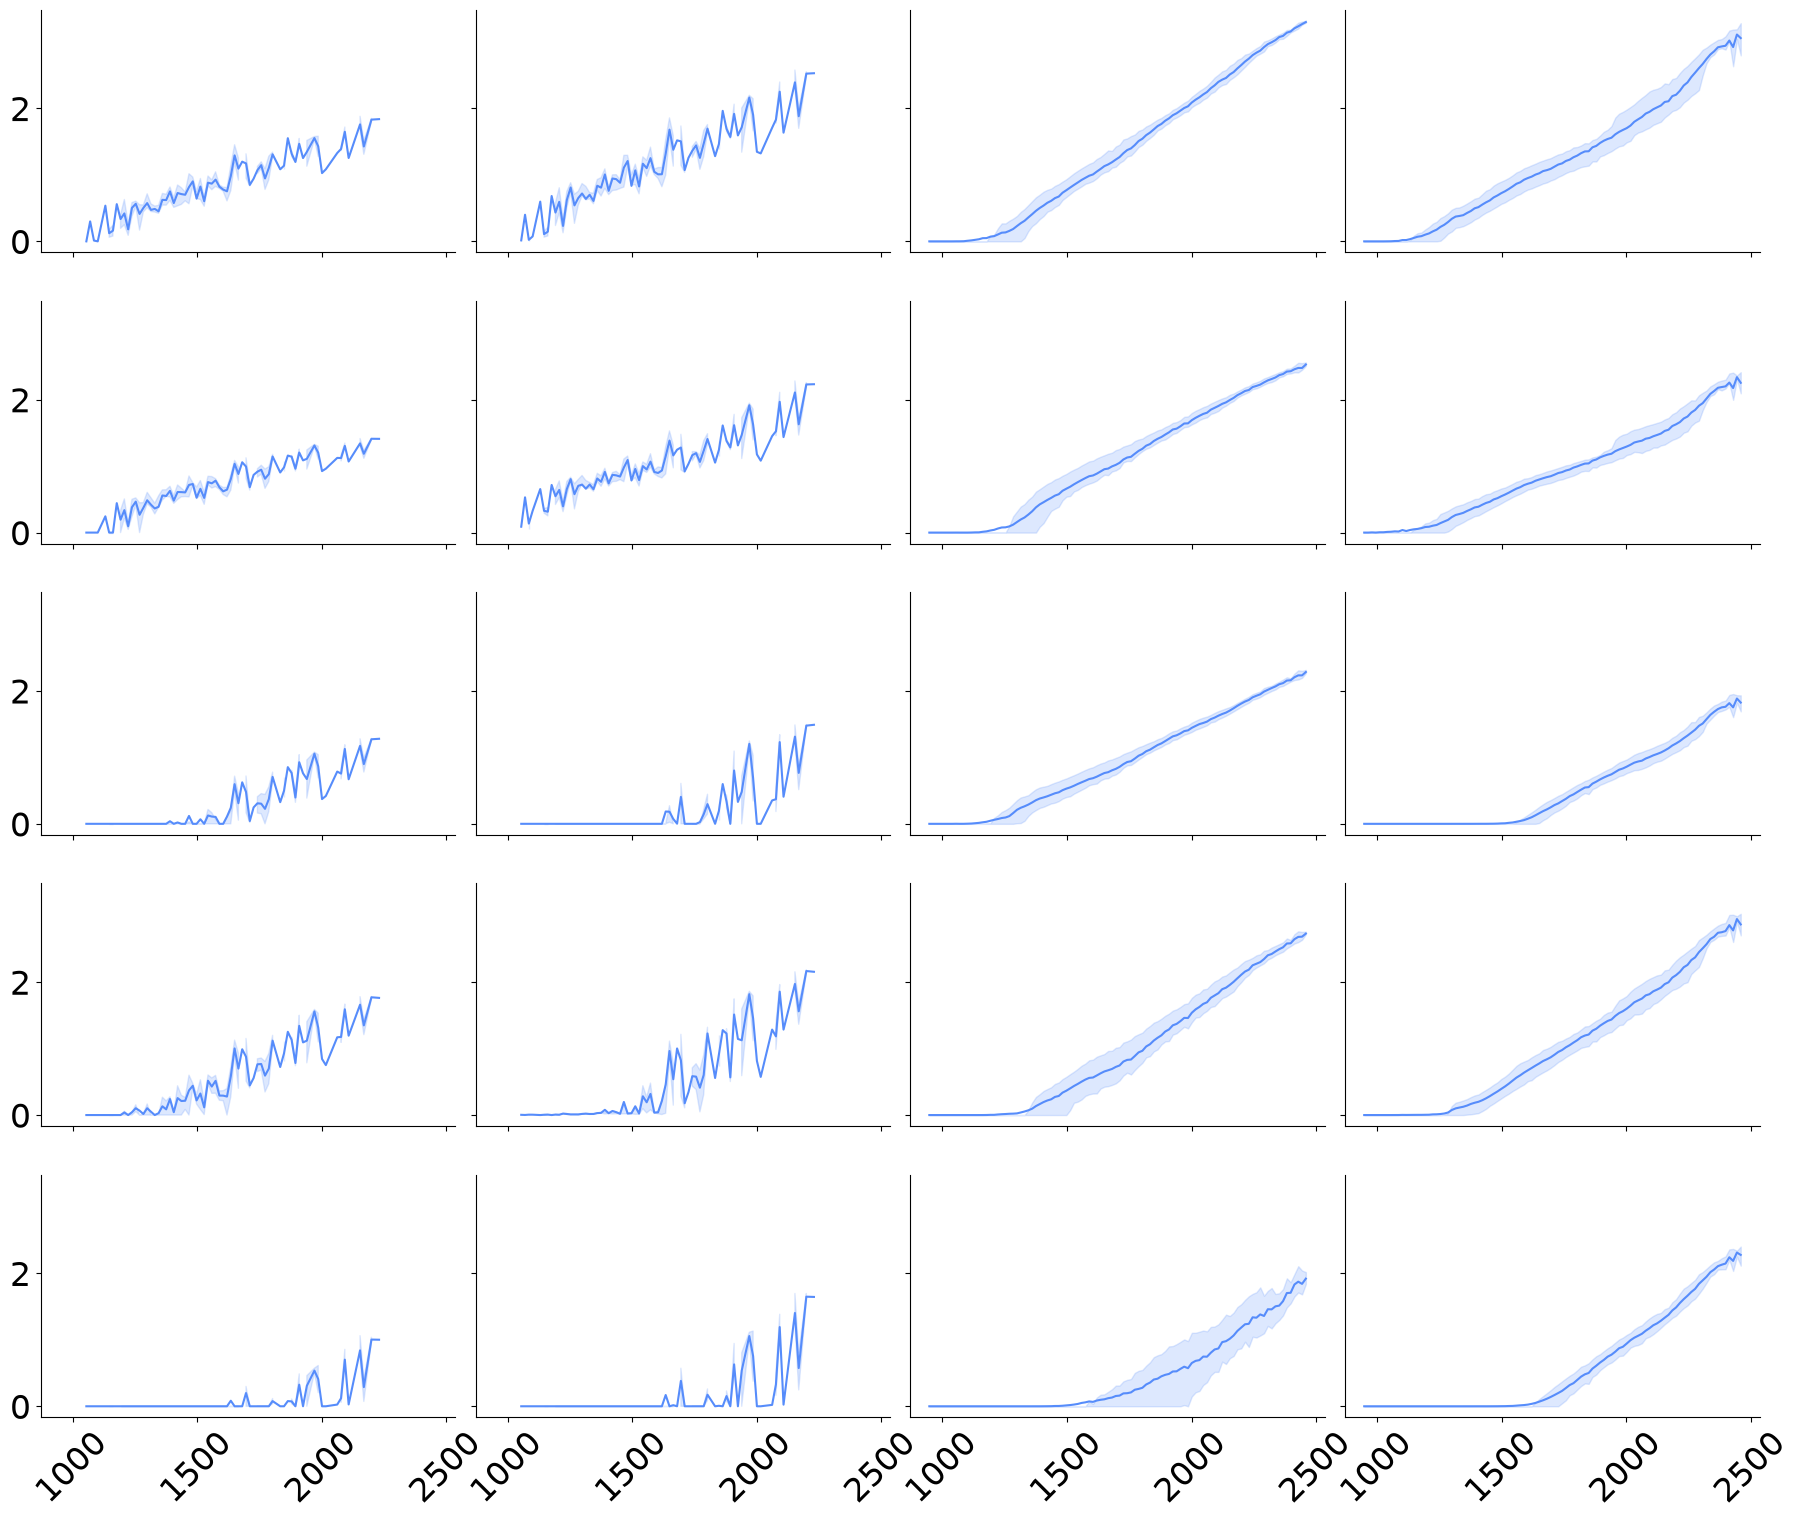

In [5]:
# 1. Create the bins using your actual combined dataframe 'snow_depth'
Task1_basin['Elevation Bin'] = pd.cut(Task1_basin['Elevation'], bins=100)
Task1_basin['Elevation Plot'] = Task1_basin['Elevation Bin'].apply(lambda x: x.mid).astype(float)

# 3. Create the matrix of ribbon plots
g = sns.relplot(
    data=Task1_basin,
    x='Elevation Plot',
    y='Snow Depth',
    row='Date',
    col='Model',
    kind='line',
    estimator='mean',
    errorbar=('pi', 50),
    height=3,
    aspect=1.5,
    facet_kws={'sharey': True, 'sharex': True}
)

g.figure.subplots_adjust(
    wspace=0.05,   # default is much larger (~0.2﷿﷿﷿0.3)
    hspace=0.2
)

# Optional: makes sure labels don﷿﷿﷿t get clipped
g.set_axis_labels("", "", fontsize=22)
g.tick_params(axis='x', labelsize=24, rotation=45)
g.tick_params(axis='y', labelsize=24)
g.set_titles("")

plt.savefig("C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/ribbon_plots.png", dpi = 300,
            bbox_inches="tight"
            )
plt.show()


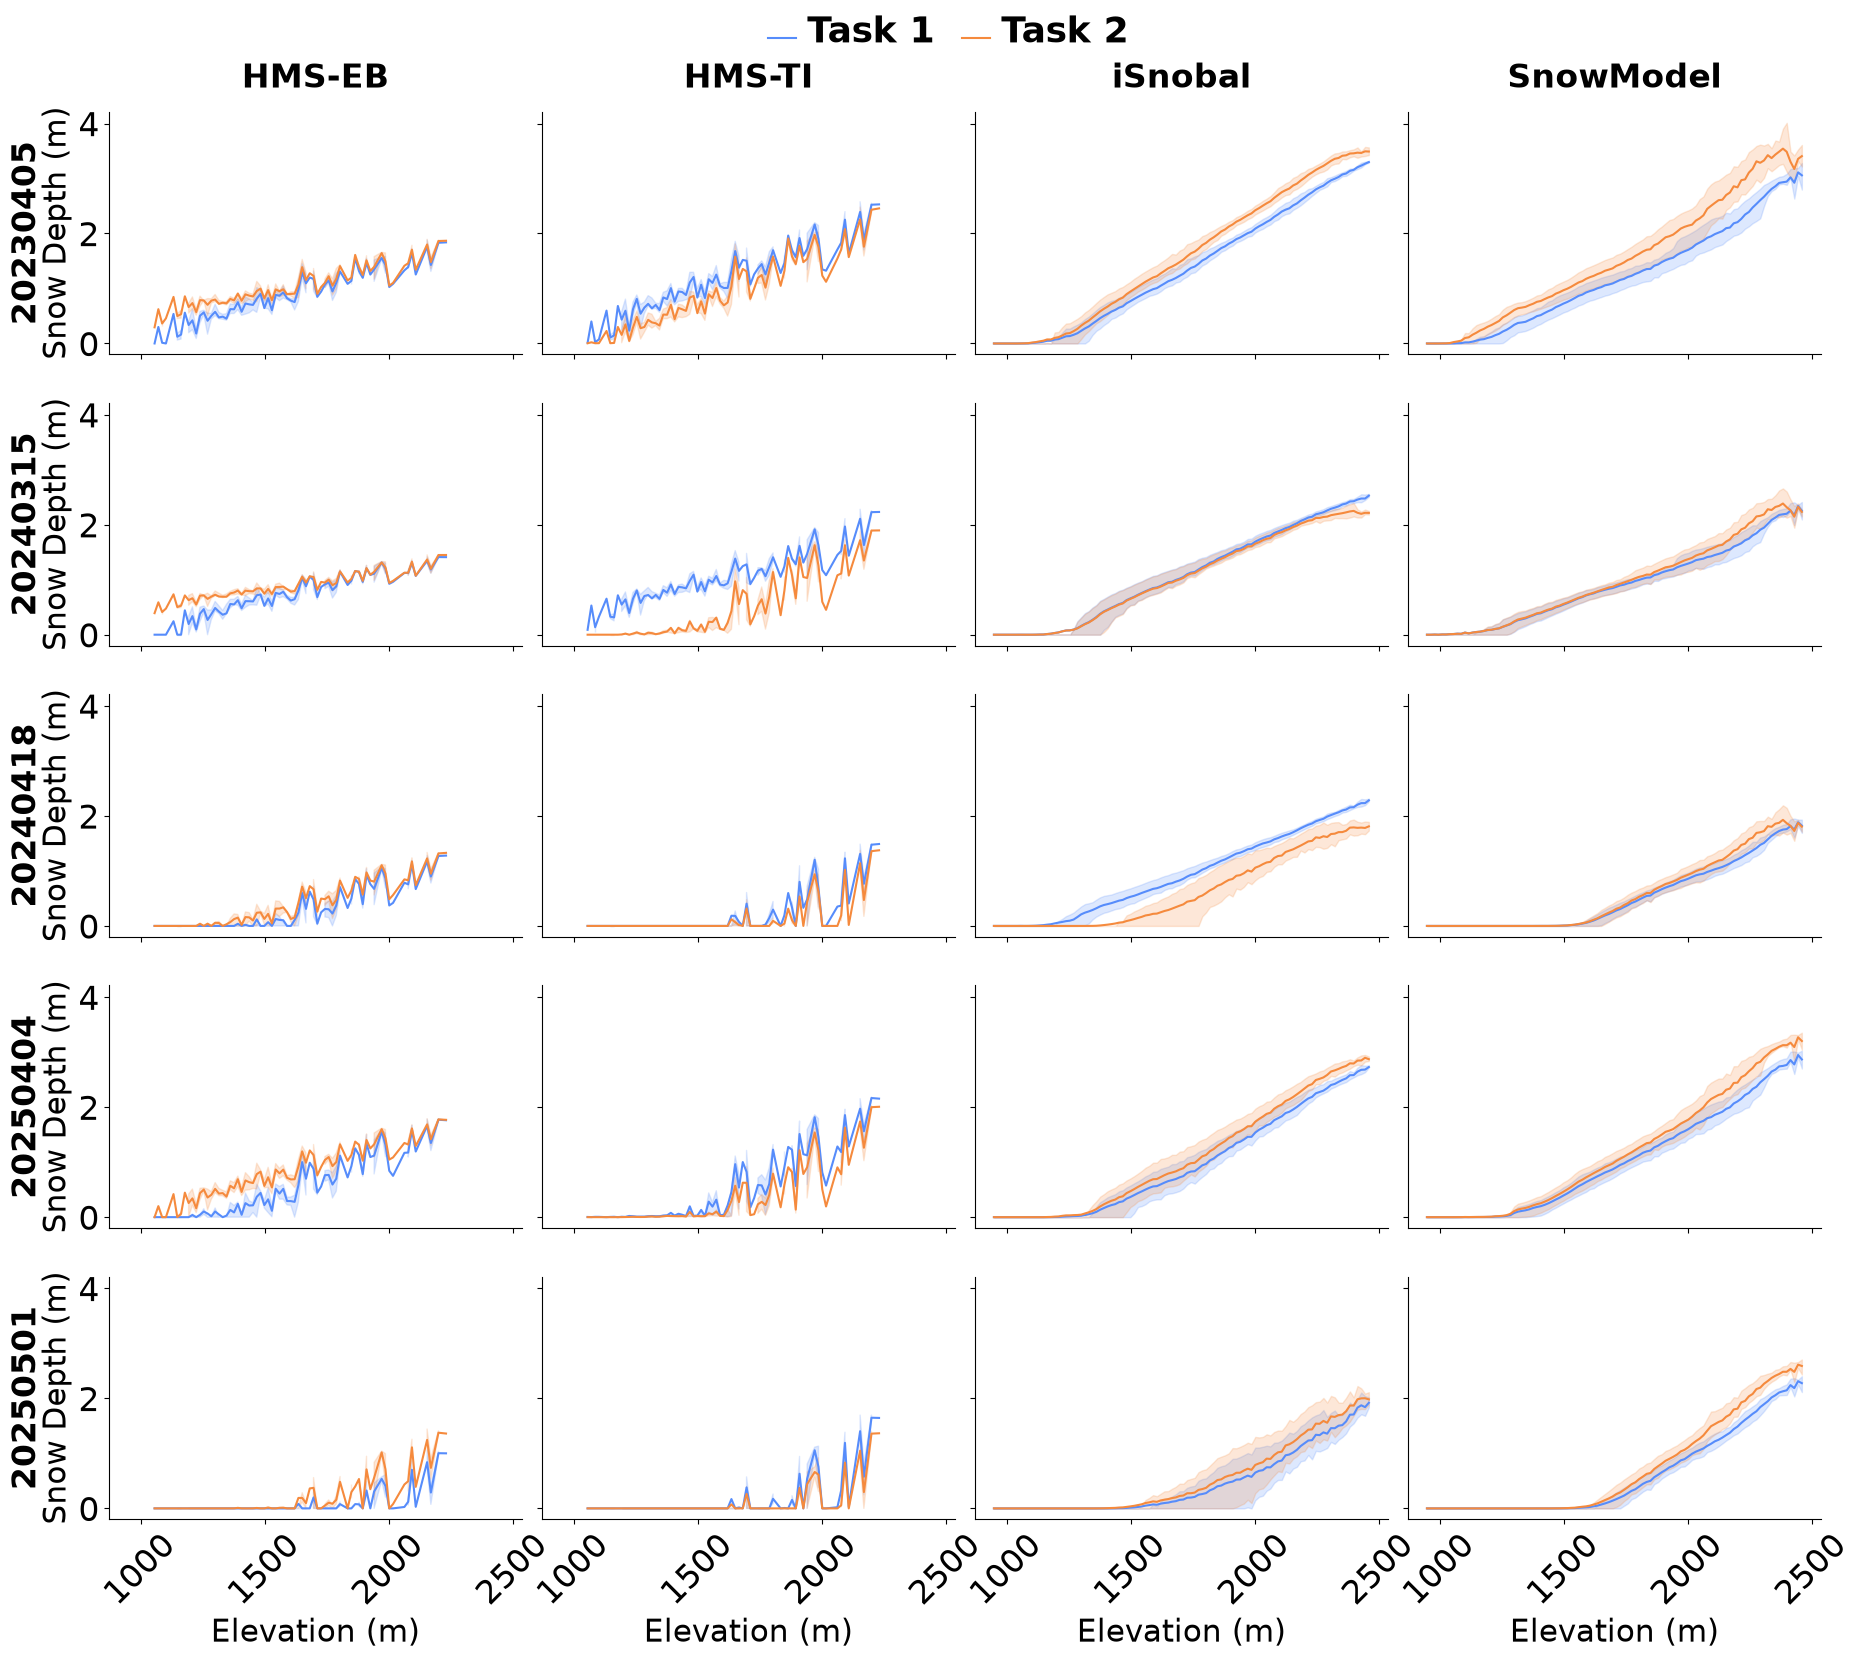

In [6]:
snow_depth['Elevation Bin'] = pd.cut(snow_depth['Elevation'], bins=100)

# 2. Extract the numeric midpoint of the bin for the X-axis plotting
snow_depth['Elevation Plot'] = snow_depth['Elevation Bin'].apply(lambda x: x.mid).astype(float)
g = sns.relplot(
    data=snow_depth,
    x='Elevation Plot',
    y='Snow Depth',
    row='Date',
    col='Model',
    hue='Task',
    kind='line',
    estimator='mean',
    errorbar=('pi', 50),
    height=3,
    aspect=1.5,
    facet_kws={'sharey': True, 'sharex': True}
)

g.figure.subplots_adjust(
    wspace=0.05,   # default is much larger (~0.2﷿﷿﷿0.3)
    hspace=0.2
)

# Optional: makes sure labels don﷿﷿﷿t get clipped
g.set_axis_labels("Elevation (m)", "Snow Depth (m)", fontsize=22)
g.tick_params(axis='x', labelsize=24, rotation=45)
g.tick_params(axis='y', labelsize=24)
g.set_titles("")

row_labels = snow_depth['Date'].unique()
for i, ax in enumerate(g.axes[:, 0]):
    ax.annotate(
        row_labels[i],
        xy=(-.2, 0.5),
        xycoords='axes fraction',
        rotation=90,
        va='center',
        ha='center',
        fontsize=24,
        fontweight='bold'
    )

col_labels = snow_depth['Model'].unique()
for i, ax in enumerate(g.axes[0, :]):
    ax.annotate(
        col_labels[i],
        xy=(0.5, 1.1),
        xycoords='axes fraction',
        ha='center',
      #  va='bottom',
        fontsize=24,
        fontweight='bold'
    )

sns.move_legend(g, "upper center", bbox_to_anchor=(0.48, 1.05), ncol = 2, markerscale=5)
plt.setp(g._legend.get_texts(), fontsize=26, fontweight='bold')
g.legend.set_title("")
plt.savefig("C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/ribbon_plots_both.png", dpi = 300,
            bbox_inches="tight")
plt.show()